In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
df = pd.read_csv('/kaggle/input/crime-prediction-in-chicago-in-2022/Crime Prediction in Chicago_Dataset.csv')
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,12592454,JF113025,1/14/2022 15:55,067XX S MORGAN ST,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,True,724,7,16.0,68,26,1170805.0,1860170.0,2022,9/14/2023 15:41,41.771782,-87.649437,"(41.771782439, -87.649436929)"
1,12785595,JF346553,8/5/2022 21:00,072XX S UNIVERSITY AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,APARTMENT,True,False,324,3,5.0,69,17,1185135.0,1857211.0,2022,9/14/2023 15:41,41.763338,-87.597001,"(41.763337967, -87.597001131)"
2,12808281,JF373517,8/14/2022 14:00,055XX W ARDMORE AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,1621,16,39.0,11,17,1138383.0,1937953.0,2022,9/14/2023 15:41,41.985875,-87.766404,"(41.985875279, -87.766403857)"
3,12888104,JF469015,11/10/2022 3:47,072XX S MAY ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,733,7,17.0,68,15,1169903.0,1856822.0,2022,9/14/2023 15:41,41.762615,-87.652840,"(41.76261474, -87.652840463)"
4,13209277,JG422539,8/15/2022 9:00,0000X W JACKSON BLVD,810,THEFT,OVER $500,COMMERCIAL / BUSINESS OFFICE,False,False,113,1,4.0,32,6,NaN,NaN,2022,9/14/2023 15:43,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239558 entries, 0 to 239557
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    239558 non-null  int64  
 1   Case Number           239558 non-null  object 
 2   Date                  239558 non-null  object 
 3   Block                 239558 non-null  object 
 4   IUCR                  239558 non-null  object 
 5   Primary Type          239558 non-null  object 
 6   Description           239558 non-null  object 
 7   Location Description  238593 non-null  object 
 8   Arrest                239558 non-null  bool   
 9   Domestic              239558 non-null  bool   
 10  Beat                  239558 non-null  int64  
 11  District              239558 non-null  int64  
 12  Ward                  239548 non-null  float64
 13  Community Area        239558 non-null  int64  
 14  FBI Code              239558 non-null  object 
 15  

In [4]:
df.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                    float64
Community Area            int64
FBI Code                 object
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [5]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,239558.0,1.273144e+07,708201.948304,26543.000000,1.267802e+07,1.276893e+07,1.285704e+07,1.363051e+07
Beat,239558.0,1.154023e+03,707.909870,111.000000,5.330000e+02,1.033000e+03,1.731000e+03,2.535000e+03
District,239558.0,1.131053e+01,7.075550,1.000000,5.000000e+00,1.000000e+01,1.700000e+01,3.100000e+01
Ward,239548.0,2.338503e+01,14.210565,1.000000,9.000000e+00,2.400000e+01,3.500000e+01,5.000000e+01
Community Area,239558.0,3.626847e+01,21.553814,1.000000,2.200000e+01,3.200000e+01,5.300000e+01,7.700000e+01
X Coordinate,234891.0,1.165381e+06,16793.753273,0.000000,1.153949e+06,1.167256e+06,1.176856e+06,1.205119e+06
Y Coordinate,234891.0,1.887038e+06,32295.639692,0.000000,1.859284e+06,1.893383e+06,1.910066e+06,1.951493e+06
Year,239558.0,2.022000e+03,0.000000,2022.000000,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03
Latitude,234891.0,4.184561e+01,0.088833,36.619446,4.176917e+01,4.186307e+01,4.190902e+01,4.202255e+01
Longitude,234891.0,-8.766860e+01,0.061010,-91.686566,-8.771015e+01,-8.766147e+01,-8.762640e+01,-8.752453e+01


In [18]:
df.isnull().notnull().sum()/len(df*100)

ID                      1.0
Case Number             1.0
Date                    1.0
Block                   1.0
IUCR                    1.0
Primary Type            1.0
Description             1.0
Location Description    1.0
Arrest                  1.0
Domestic                1.0
Beat                    1.0
District                1.0
Ward                    1.0
Community Area          1.0
FBI Code                1.0
X Coordinate            1.0
Y Coordinate            1.0
Year                    1.0
Updated On              1.0
Latitude                1.0
Longitude               1.0
Location                1.0
dtype: float64

In [27]:
df.shape

(239558, 22)

<Axes: >

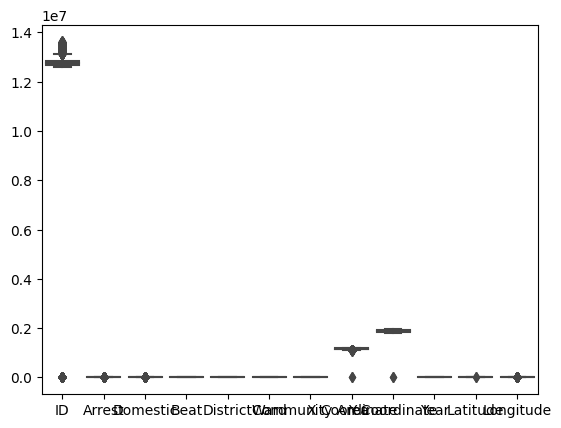

In [30]:
sns.boxplot(df)

<Axes: >

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


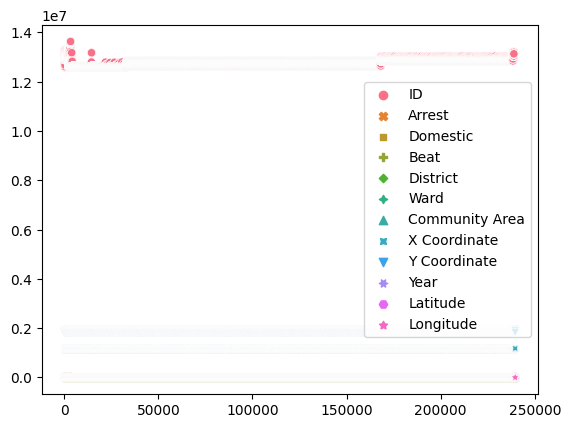

In [31]:
sns.scatterplot(df)

<Axes: >

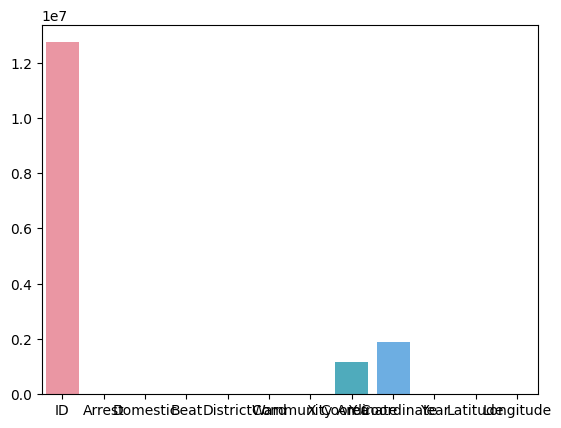

In [62]:
sns.barplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


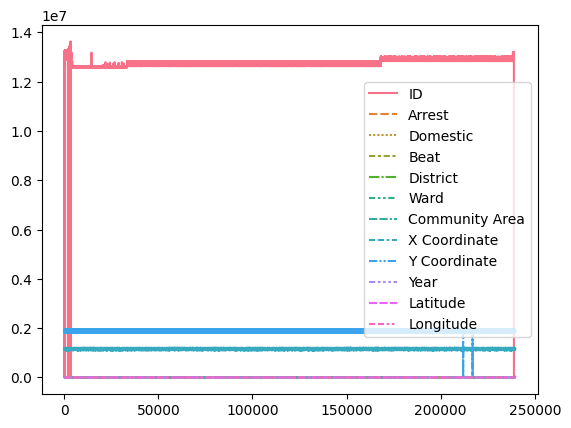

In [63]:
sns.lineplot(df)

<Axes: >

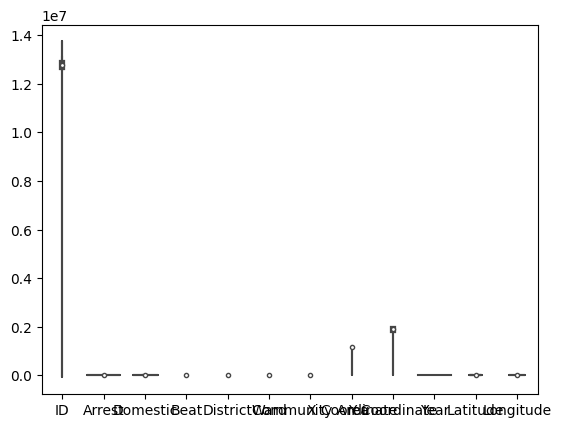

In [69]:
sns.violinplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_stats/counting.py:137: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bin_edges = np.histogram_bin_edges(vals, bins, binrange, weight)
/usr/local/lib/python3.10/dist-packages/seaborn/_stats/counting.py:176: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, edges = np.histogram(vals, **bin_kws, weights=weights, density=density)
/usr/loca

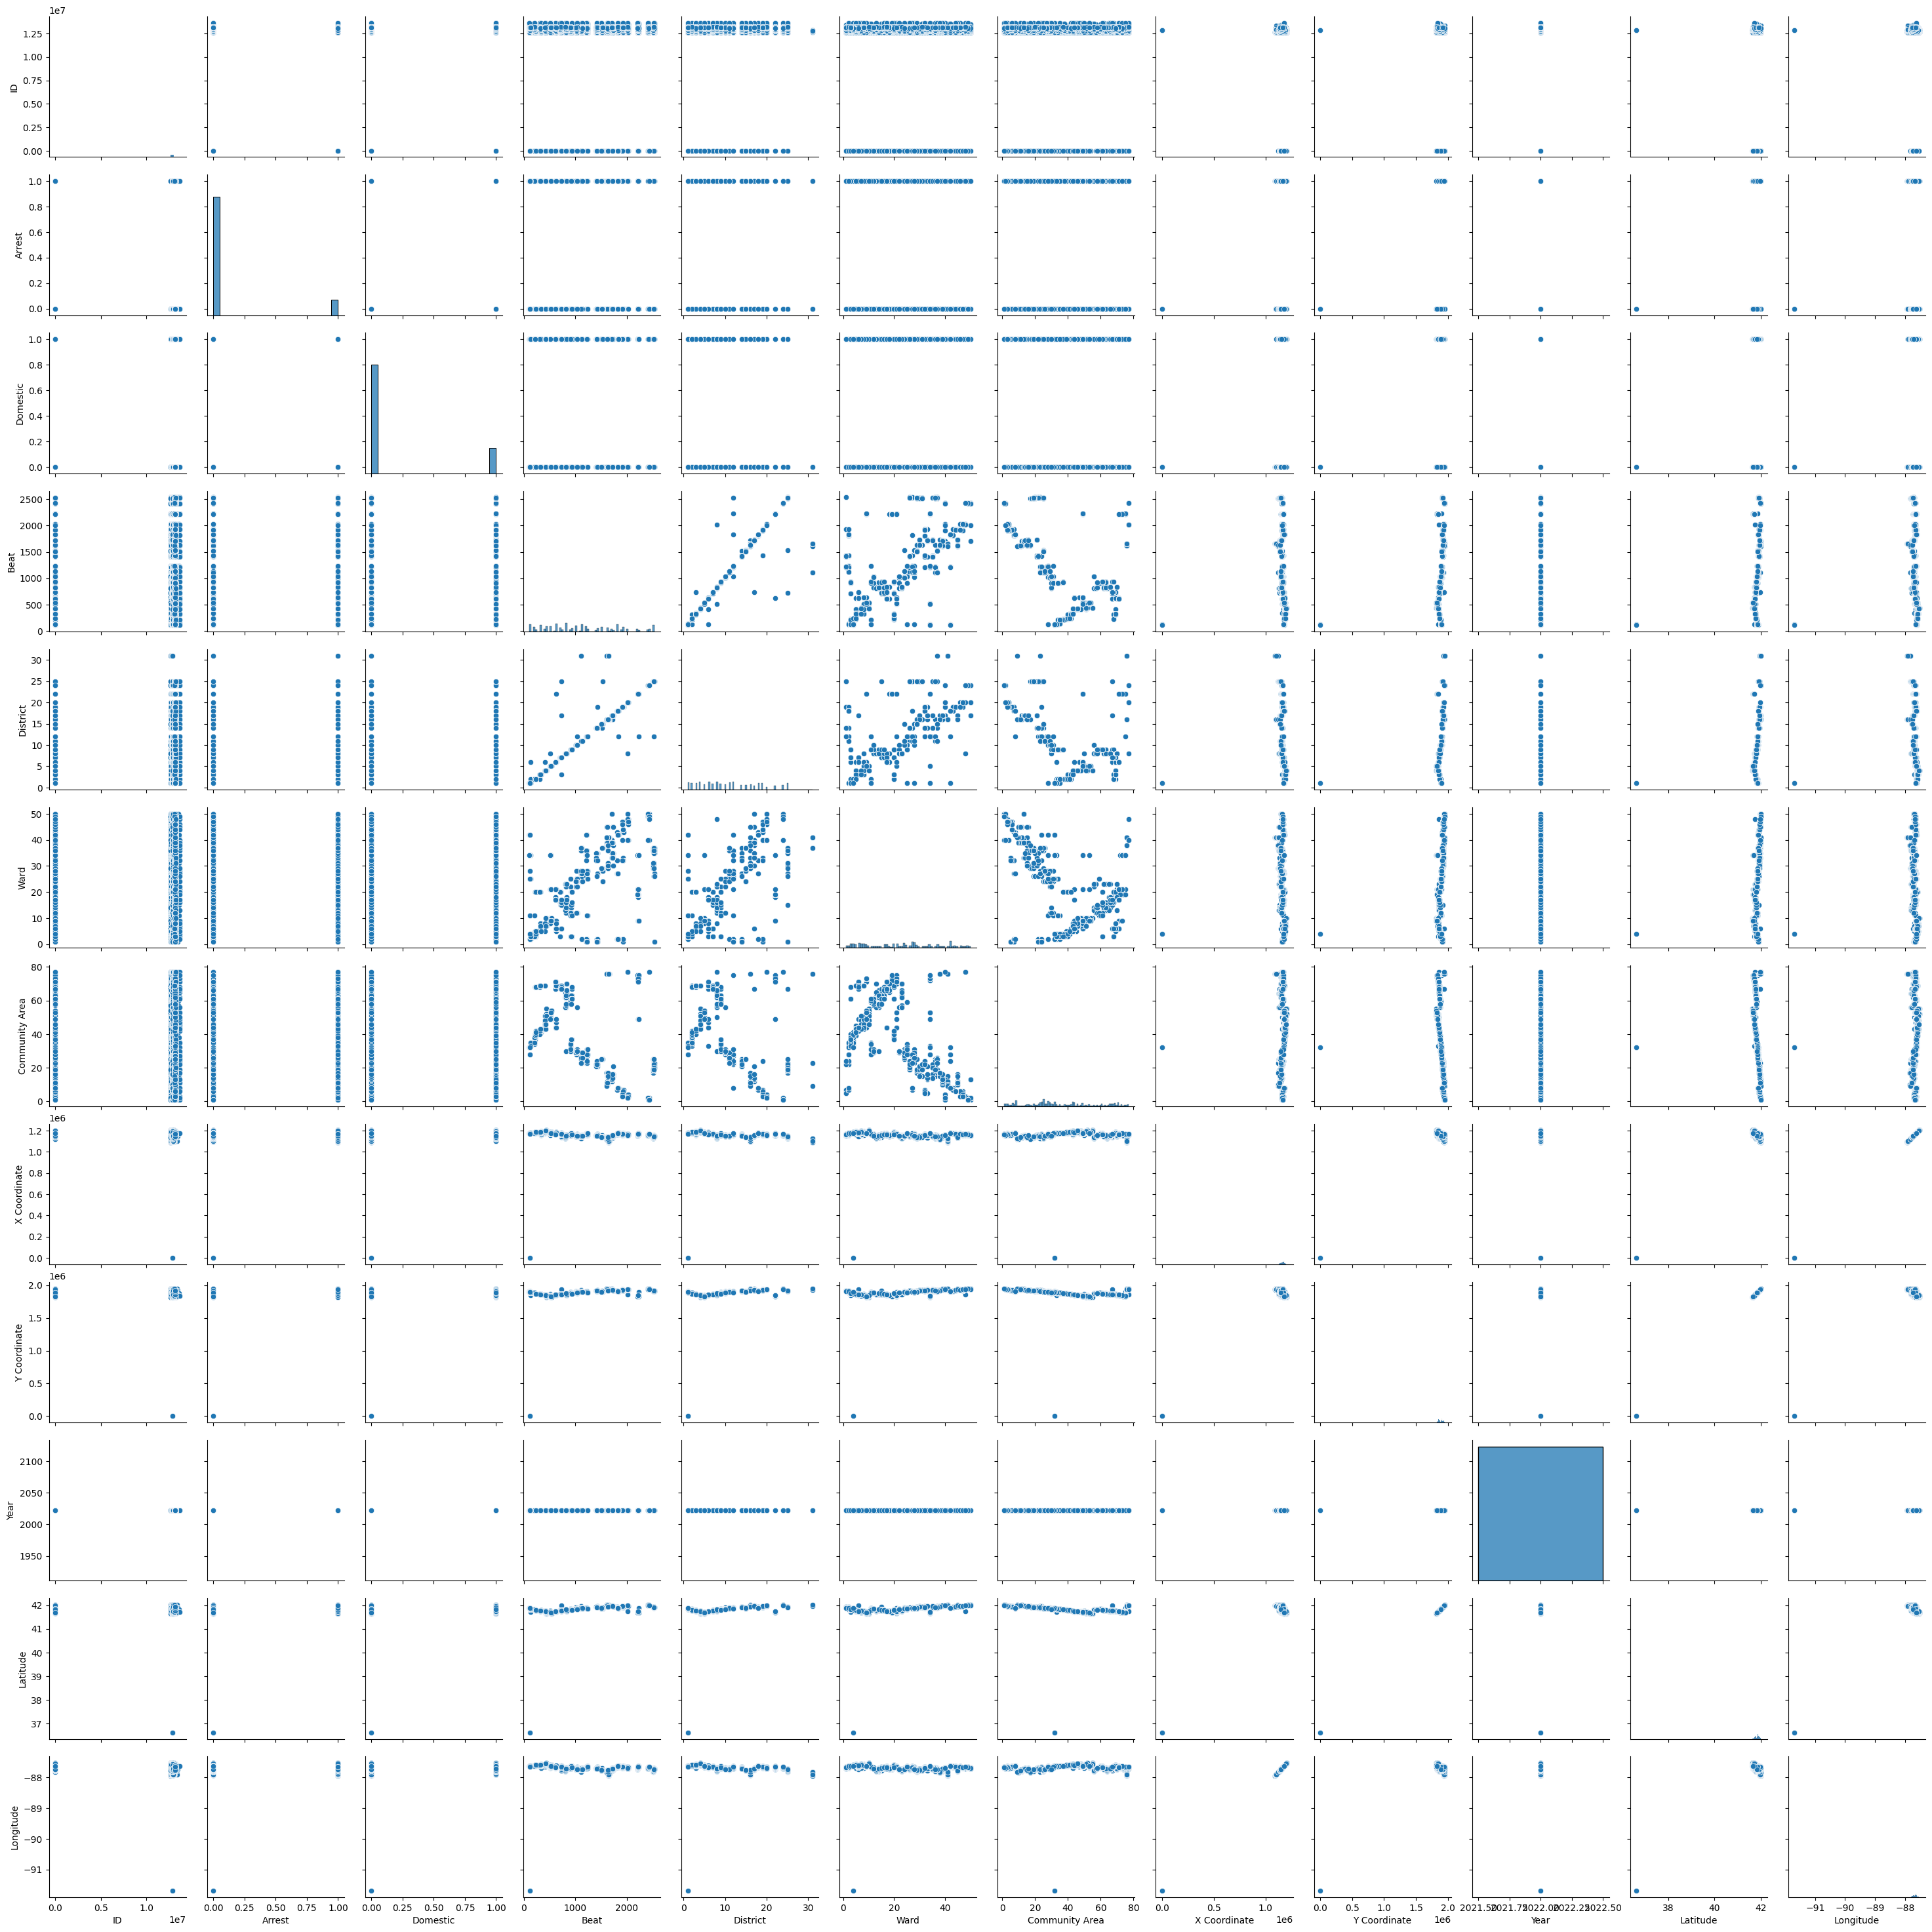

In [4]:
sns.pairplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-70-74558c0f5298>:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df)


<Axes: ylabel='Density'>

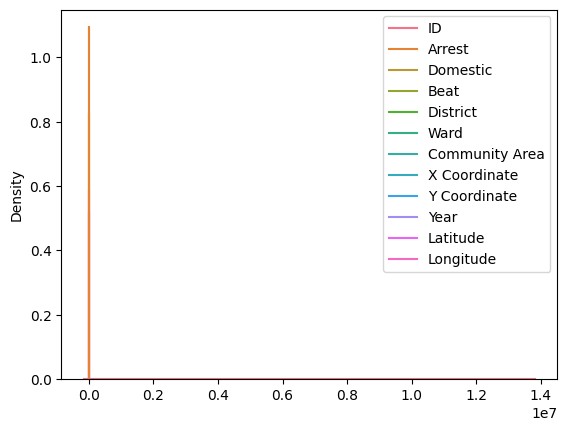

In [70]:
sns.kdeplot(df)

In [68]:
df.kurt

<bound method DataFrame.kurt of               ID Case Number             Date                   Block  IUCR  \
0       12592454    JF113025  1/14/2022 15:55       067XX S MORGAN ST  2826   
1       12785595    JF346553   8/5/2022 21:00  072XX S UNIVERSITY AVE  1544   
2       12808281    JF373517  8/14/2022 14:00     055XX W ARDMORE AVE  1562   
3       12888104    JF469015  11/10/2022 3:47          072XX S MAY ST  1477   
4       13209277    JG422539   8/15/2022 9:00    0000X W JACKSON BLVD   810   
...          ...         ...              ...                     ...   ...   
239553     27038    JF387886   9/8/2022 10:50    061XX N WINTHROP AVE   110   
239554     26819    JF275138  6/10/2022 23:41        018XX S CANAL ST   110   
239555     26601    JF132803   2/3/2022 16:27        000XX E 100TH PL   110   
239556     26857    JF290575   6/23/2022 2:25     027XX S KEDVALE AVE   110   
239557     27015    JF377220   8/31/2022 9:30    116XX S MICHIGAN AVE   110   

             Primar

In [66]:
df.skew

<bound method DataFrame.skew of               ID Case Number             Date                   Block  IUCR  \
0       12592454    JF113025  1/14/2022 15:55       067XX S MORGAN ST  2826   
1       12785595    JF346553   8/5/2022 21:00  072XX S UNIVERSITY AVE  1544   
2       12808281    JF373517  8/14/2022 14:00     055XX W ARDMORE AVE  1562   
3       12888104    JF469015  11/10/2022 3:47          072XX S MAY ST  1477   
4       13209277    JG422539   8/15/2022 9:00    0000X W JACKSON BLVD   810   
...          ...         ...              ...                     ...   ...   
239553     27038    JF387886   9/8/2022 10:50    061XX N WINTHROP AVE   110   
239554     26819    JF275138  6/10/2022 23:41        018XX S CANAL ST   110   
239555     26601    JF132803   2/3/2022 16:27        000XX E 100TH PL   110   
239556     26857    JF290575   6/23/2022 2:25     027XX S KEDVALE AVE   110   
239557     27015    JF377220   8/31/2022 9:30    116XX S MICHIGAN AVE   110   

             Primar

In [38]:
cat_cols = df.select_dtypes(include='object')

In [47]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print(''*100)





Case Number

Date

Block

IUCR

Primary Type

Description

Location Description

FBI Code

Updated On

Location



In [40]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,12592454,JF113025,1/14/2022 15:55,067XX S MORGAN ST,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,True,724,7,16.0,68,26,1170805.0,1860170.0,2022,9/14/2023 15:41,41.771782,-87.649437,"(41.771782439, -87.649436929)"
1,12785595,JF346553,8/5/2022 21:00,072XX S UNIVERSITY AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,APARTMENT,True,False,324,3,5.0,69,17,1185135.0,1857211.0,2022,9/14/2023 15:41,41.763338,-87.597001,"(41.763337967, -87.597001131)"
2,12808281,JF373517,8/14/2022 14:00,055XX W ARDMORE AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,1621,16,39.0,11,17,1138383.0,1937953.0,2022,9/14/2023 15:41,41.985875,-87.766404,"(41.985875279, -87.766403857)"
3,12888104,JF469015,11/10/2022 3:47,072XX S MAY ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,733,7,17.0,68,15,1169903.0,1856822.0,2022,9/14/2023 15:41,41.762615,-87.652840,"(41.76261474, -87.652840463)"
4,13209277,JG422539,8/15/2022 9:00,0000X W JACKSON BLVD,810,THEFT,OVER $500,COMMERCIAL / BUSINESS OFFICE,False,False,113,1,4.0,32,6,NaN,NaN,2022,9/14/2023 15:43,NaN,NaN,NaN


In [48]:
num_cols = df.select_dtypes(include='number')

In [50]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print(''*50)

ID

Beat

District

Ward

Community Area

X Coordinate

Y Coordinate

Year

Latitude

Longitude



In [61]:
df.corr

<bound method DataFrame.corr of               ID Case Number             Date                   Block  IUCR  \
0       12592454    JF113025  1/14/2022 15:55       067XX S MORGAN ST  2826   
1       12785595    JF346553   8/5/2022 21:00  072XX S UNIVERSITY AVE  1544   
2       12808281    JF373517  8/14/2022 14:00     055XX W ARDMORE AVE  1562   
3       12888104    JF469015  11/10/2022 3:47          072XX S MAY ST  1477   
4       13209277    JG422539   8/15/2022 9:00    0000X W JACKSON BLVD   810   
...          ...         ...              ...                     ...   ...   
239553     27038    JF387886   9/8/2022 10:50    061XX N WINTHROP AVE   110   
239554     26819    JF275138  6/10/2022 23:41        018XX S CANAL ST   110   
239555     26601    JF132803   2/3/2022 16:27        000XX E 100TH PL   110   
239556     26857    JF290575   6/23/2022 2:25     027XX S KEDVALE AVE   110   
239557     27015    JF377220   8/31/2022 9:30    116XX S MICHIGAN AVE   110   

             Primar

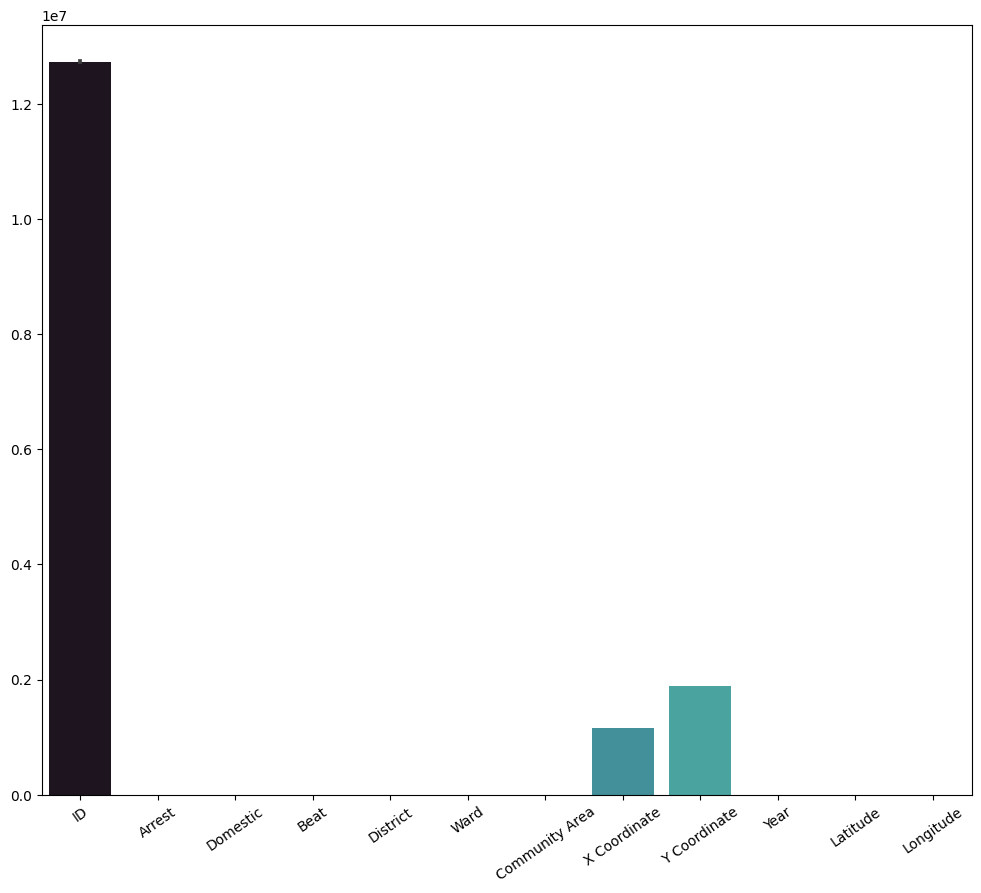

In [53]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,palette='mako')
plt.xticks(rotation=35);
plt.show()

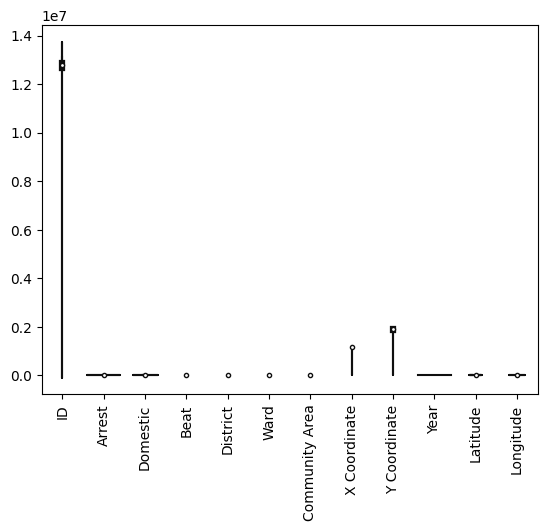

In [56]:
sns.violinplot(data=df,palette='mako')
plt.xticks(rotation=90);
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


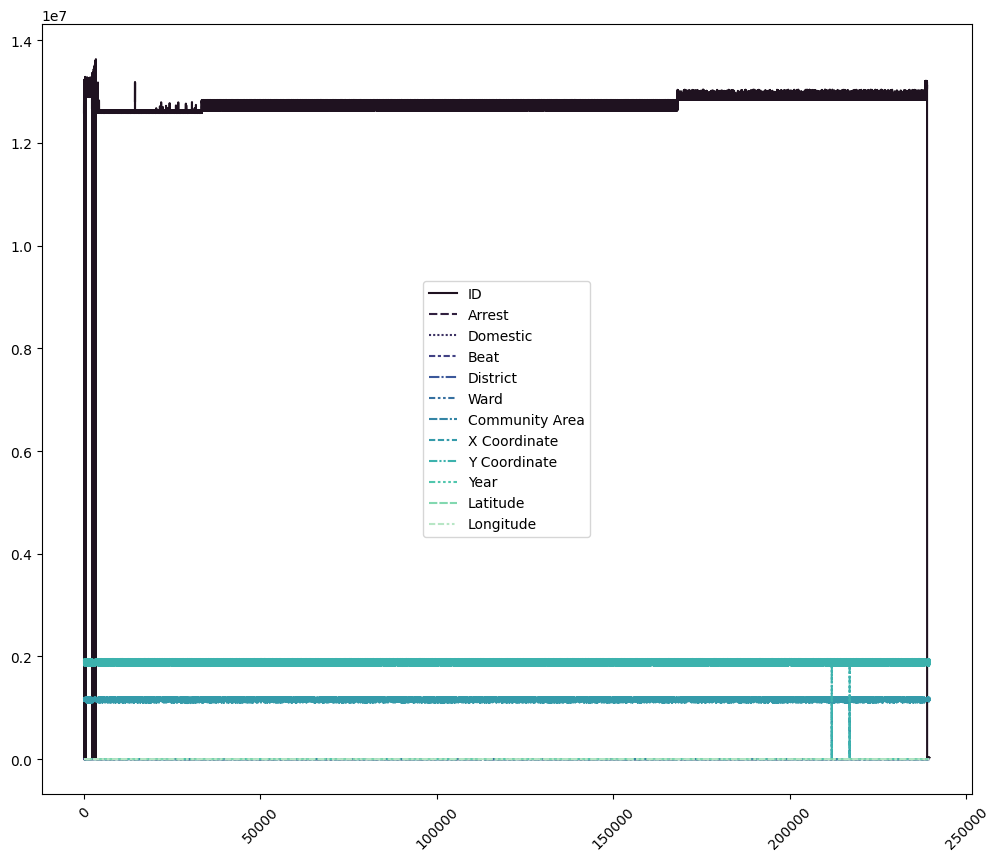

In [58]:
plt.figure(figsize=(12,10))
sns.lineplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

Case Number


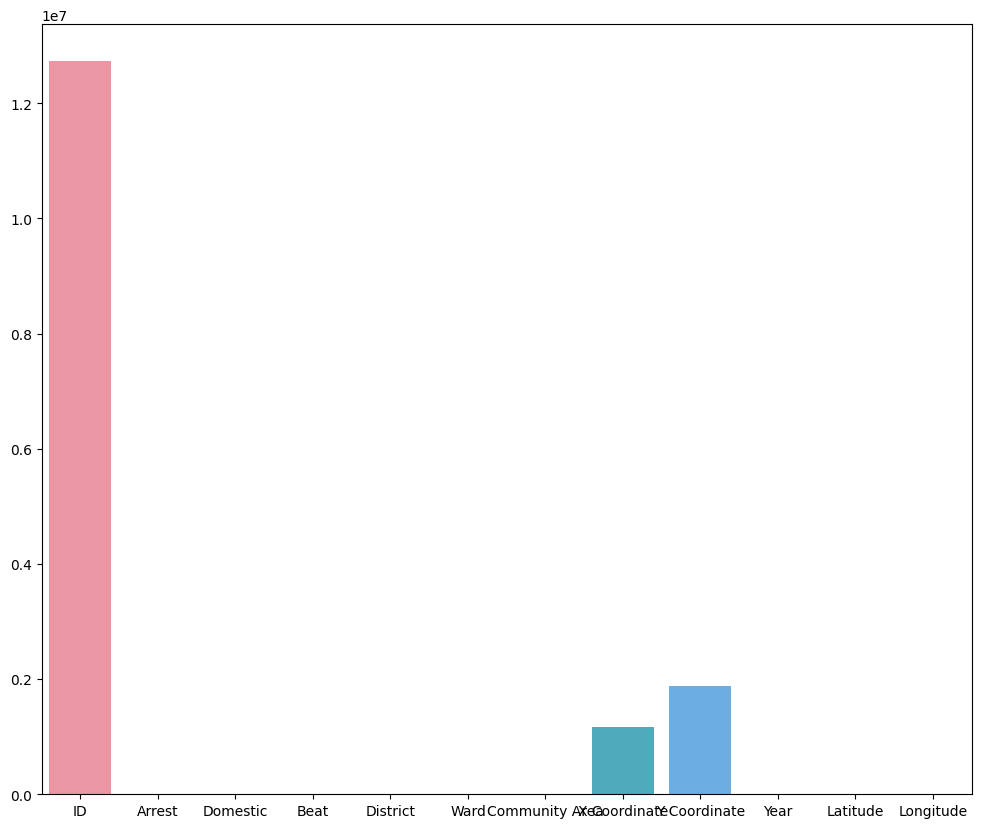

Date


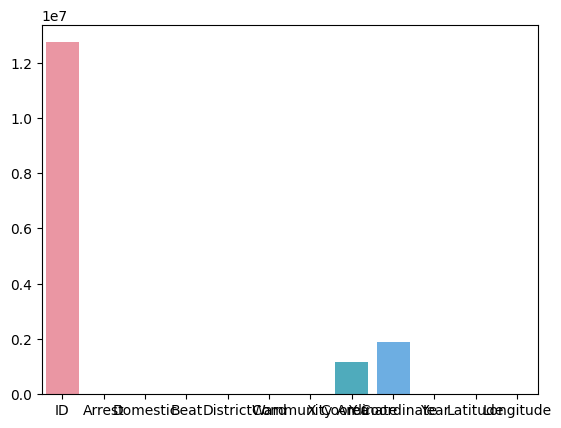

Block


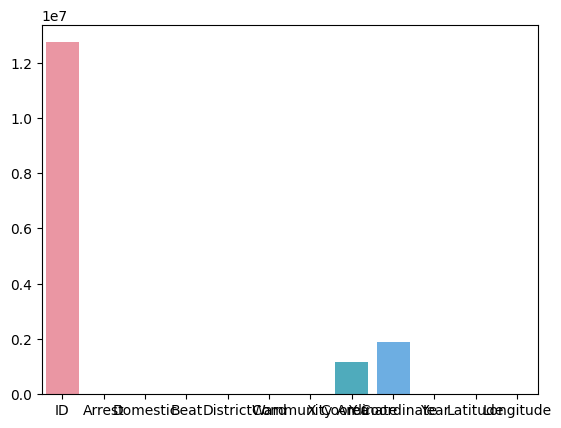

IUCR


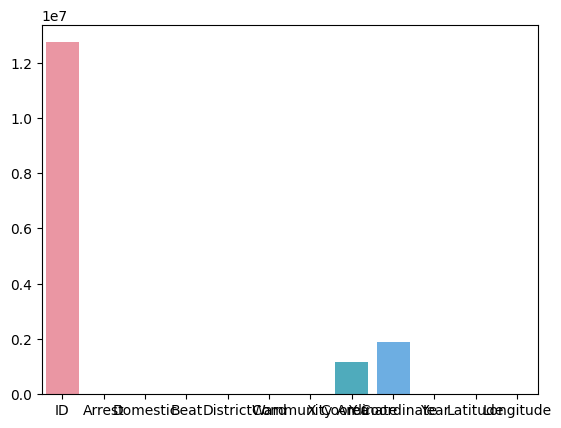

Primary Type


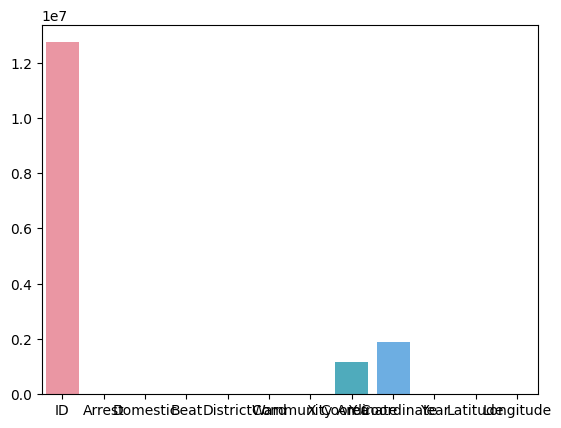

Description


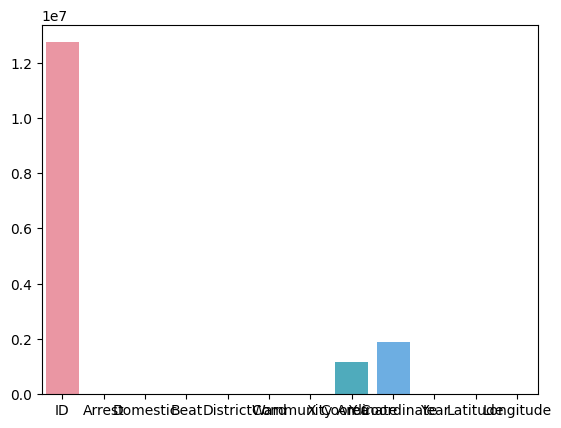

Location Description


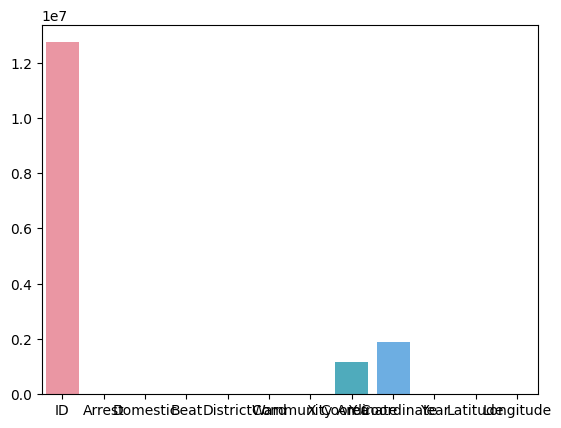

FBI Code


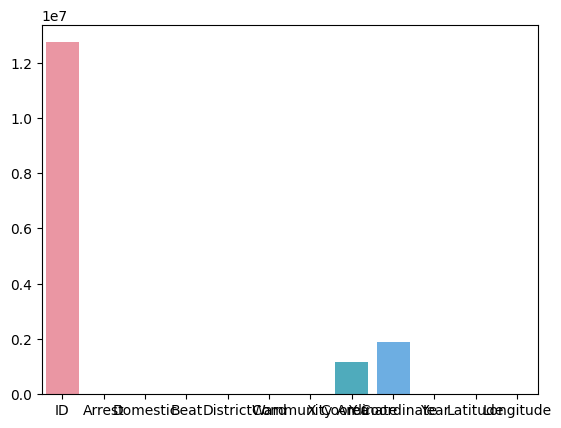

Updated On


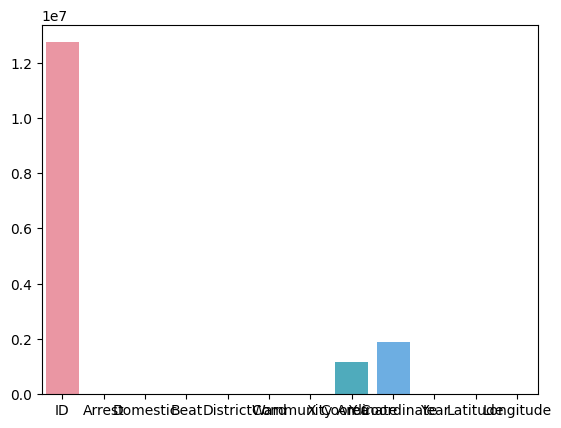

Location


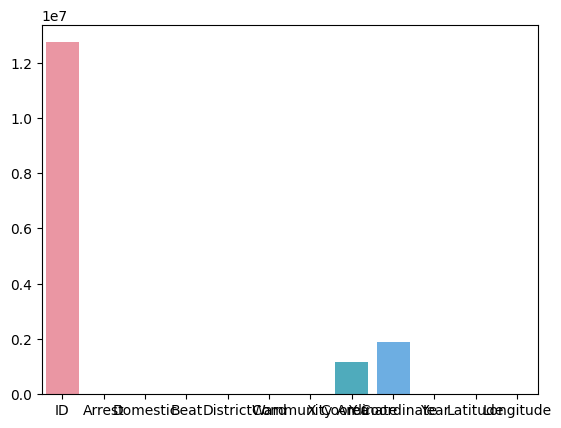

In [78]:
x = i
plt.figure(figsize=(12,10))
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.barplot(data=df)
    print(i) 
    plt.show()


ID


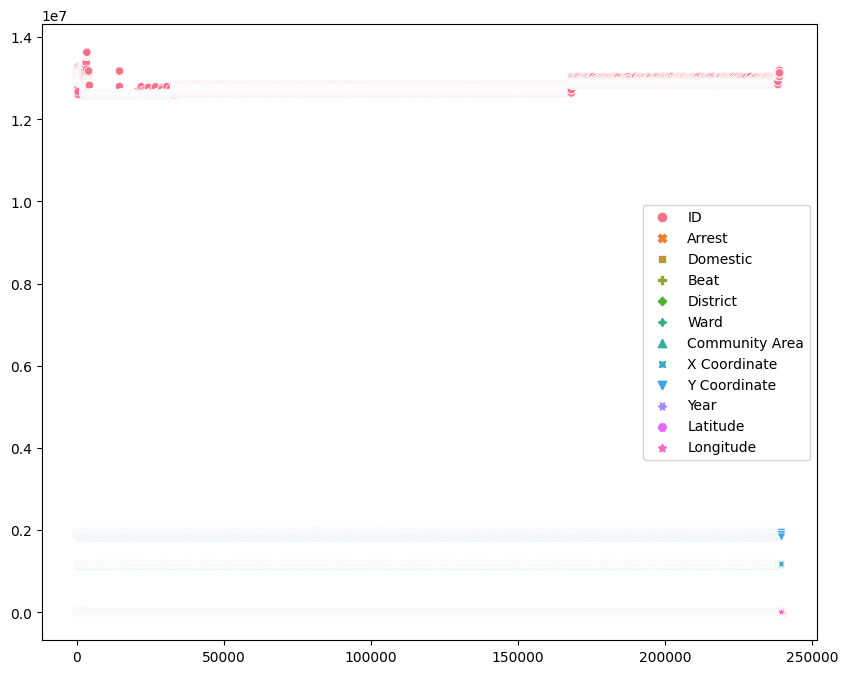

Beat


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


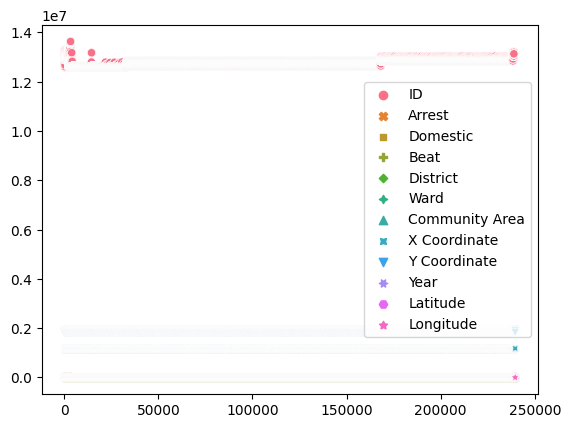

District


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
x = i
plt.figure(figsize=(10,8))
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.scatterplot(data=df)
    print(i) 
    plt.show()